In [34]:
import os

from pathlib import Path
from typing import TypedDict, List, Annotated, Literal, Optional, Dict
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

from langchain_openrouter import ChatOpenRouter
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.vectorstores import InMemoryVectorStore

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters  import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_core.prompts import ChatPromptTemplate
import operator
from langchain_core.tools import tool
from dotenv import load_dotenv


In [35]:
# states
class PaperSummary(BaseModel):
    title: str = Field(...,description="The official title of the paper")
    problem_domain: str = Field(..., description="The specific problem being solved (e.g., Tabular Data Classification, Time Series Forecasting).")
    authors: List[str] = Field(..., description="List of the paper's authors.")
    publication_year: Optional[int] = Field(default=None, description="The year the paper was published.")
    code_repository_url: Optional[str] = Field(
        default=None, 
        description="URL to the GitHub or code repository if provided in the text."
    )
    
    novel_architecture_proposed: Optional[str] = Field(
        default=None,
        description="Name of the new model proposed (e.g., FT-Transformer) i.e the originality of this paper. Return null if it's a survey or comparative study."
    )
    models_evaluated: List[str] = Field(..., description="List of all models tested or compared (e.g., XGBoost, ResNet, TabNet). DO NOT include optimizers (e.g., Adam), regularization techniques (e.g., Dropout), or datasets.")
    datasets_used: List[str] = Field(..., description="List of specific datasets used for benchmarking (e.g., Adult, Higgs, California Housing).")
    
    evaluation_metrics: List[str] = Field(..., description="Metrics used to measure performance (e.g., RMSE, Accuracy, F1-score).")
    
    main_conclusion: str = Field(..., description="The primary finding or takeaway of the research.")
    key_limitations: Optional[str] = Field(
        default=None, 
        description="Any stated limitations, failures, or disadvantages mentioned by the authors."
    )
    research_gap_addressed: Optional[str] = Field(
        default=None, 
        description="The specific flaw or missing piece in existing literature this paper attempts to solve (e.g., 'Previous time-series forecasting models fail to capture long-term dependencies.')."
    )
    future_research_gaps: Optional[str] = Field(
        default=None, 
        description="Unsolved problems, open questions, or future work explicitly mentioned by the authors at the end of the paper."
    )

class ResearchGraphState(TypedDict):
    pdf_paths: List[str]
    user_query: str
    extracted_summaries: Annotated[List[PaperSummary], operator.add]
    missing_fields: Dict[str, List[str]]  # Track papers needing retry
    final_comparison: Optional[str]
    

In [36]:
llm = ChatOpenRouter(
    model="cohere/north-mini-code:free",
    temperature=0
)

In [37]:
from langchain_openai import OpenAIEmbeddings
import os
load_dotenv()

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=os.getenv("OPENROUTER_API_KEY"), # type: ignore
    base_url="https://openrouter.ai/api/v1",
)

In [38]:
def extract_paper_rag(state: ResearchGraphState) -> dict: # type: ignore
    summaries = []
    
    for pdf_path in state["pdf_paths"]:
        loader = PyPDFLoader(pdf_path)
        docs = loader.load()
        splitter = RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=200)
        chunks = splitter.split_documents(docs)
        
        vector_store = InMemoryVectorStore.from_documents(chunks, embeddings)
        retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

        intro_meta_chunks = retriever.invoke("title, authors, abstract, introduction, problem domain, research gap, github code repository")
        methods_chunks = retriever.invoke("models evaluated, novel architecture proposed, methodology, experimental setup")
        results_chunks = retriever.invoke("datasets used, evaluation metrics, main conclusions, limitations, future work")

        unique_chunks = {c.page_content for c in (intro_meta_chunks + methods_chunks + results_chunks)}
        context = "\n\n".join(unique_chunks)

        structured_llm=llm.with_structured_output(PaperSummary)

        prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an expert AI researcher analyzing scientific literature. 
Your task is to extract highly accurate, factual information from the provided research paper text into the required structured format.

STRICT RULES:
1. ONLY extract information explicitly stated in the provided text.
2. DO NOT hallucinate, infer, or guess fields (especially datasets, metrics, and models).
3. If a field (like a code repository or future gap) is not mentioned in the text, leave it null/empty.
4. Keep textual summaries concise, technical, and objective."""),
    ("human", "Here is the text from the research paper:\n\n{context}\n\nExtract the requested information.")
])
        chain = prompt|structured_llm
        summary = chain.invoke({'context': context})

        summaries.append(summary)
        
    return {"extracted_summaries": summaries}


In [39]:
def comparison(state: ResearchGraphState) -> dict:
    summaries = state['extracted_summaries']
    user_query = state['user_query']
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a senior researcher. Compare the following extracted paper summaries."),
        ("human", """Here are the summaries of {num_papers} papers:

{summaries_json}

Provide:
1. A Markdown comparison matrix table of Models, Datasets, and Metrics.
2. Key points of agreement/conflict in their conclusions.
3. Identified research gaps across all papers.

Note: Directly address the user query below in your analysis.
USER QUERY: {user_query}""")
    ])

    summaries_text = "\n\n".join([s.model_dump_json(indent=2) for s in summaries])
    
    chain = prompt | llm
    response = chain.invoke({
        "num_papers": len(summaries), 
        "summaries_json": summaries_text, 
        "user_query": user_query
    })
    
    return {"final_comparison": response.content}

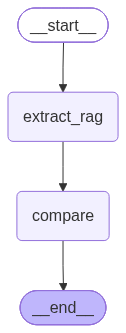

In [40]:
g=StateGraph(ResearchGraphState)
g.add_node("extract_rag",extract_paper_rag)
g.add_node("compare",comparison)

g.add_edge(START,"extract_rag")
g.add_edge("extract_rag","compare")
g.add_edge("compare",END)

graph=g.compile()
graph

In [41]:
inputs = {
    "pdf_paths": ["pdf_1.pdf", "pdf_2.pdf"],
    "user_query": "Compare their performance benchmarks and identify which paper handles tabular data better.",
    "extracted_summaries": [],
    "missing_fields": {},
    "final_comparison": None
}

result = graph.invoke(inputs) # type: ignore

print("=== FINAL COMPARISON REPORT ===")
print(result["final_comparison"])

=== FINAL COMPARISON REPORT ===
## 1. Comparison Matrix – Models, Datasets & Evaluation Metrics  

| **Model** | **Paper 1 – “Comprehensive Evaluation of Foundation Models and Neural Networks for Tabular Classification”** | **Paper 2 – “Analysis of the automl challenge series 2015‑2018”** |
|-----------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------|
| **TabPFN** | • Datasets: OpenMLCC18 (18 classification datasets)  <br>• Metric: ROC‑AUC (small‑data regime) | *Not evaluated* |
| **XGBoost** | • Datasets: OpenMLCC18  <br>• Metric: ROC‑AUC | *Not evaluated* |
| **CatBoost** | • Datasets: OpenMLCC18  <br>• Metric: ROC‑AUC | • Datasets: Adult, Helena, Jannis, Higgs, ALOI, Epsilon, Covertype, Yahoo, Microsoft (cla